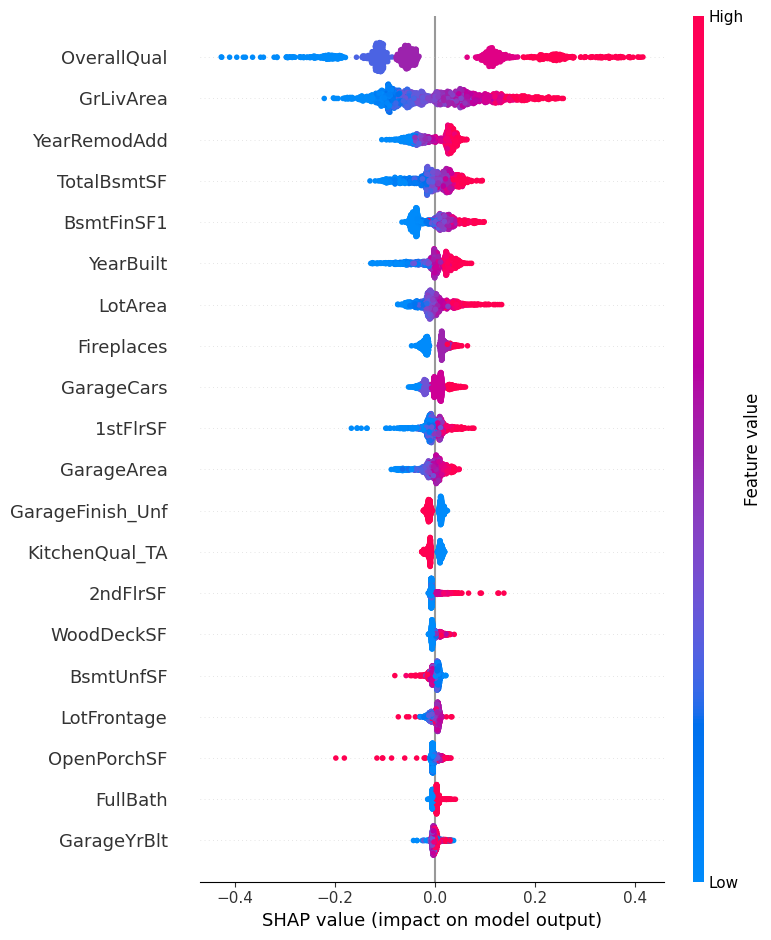

In [5]:
import shap
import pandas as pd
from xgboost import XGBRegressor

# Recharger les données (si besoin)
X_train_sel = pd.read_csv("../Data/X_train_encoded.csv")[[
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea',
    'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF',
    'FullBath', 'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr',
    'GarageYrBlt', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'MoSold', 'GarageFinish_Unf', 'KitchenQual_TA',
    'Neighborhood_NridgHt', 'BsmtQual_TA'
]]
X_train_sel = X_train_sel.fillna(0)

# Recréer et entraîner le modèle
xgb_best = XGBRegressor(
    n_estimators=659,
    max_depth=5,
    learning_rate=0.0101,
    subsample=0.518,
    colsample_bytree=0.817,
    random_state=42,
    verbosity=0
)
y_train_log = pd.read_csv("../Data/y_train_log.csv").squeeze()
xgb_best.fit(X_train_sel, y_train_log)

# SHAP
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_train_sel)
shap.summary_plot(shap_values, X_train_sel)


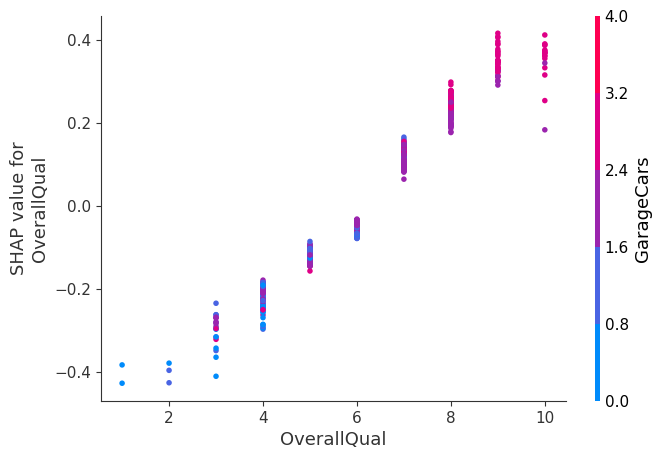

✅ SHAP summary plot sauvegardé dans 'shap_summary_plot.png'


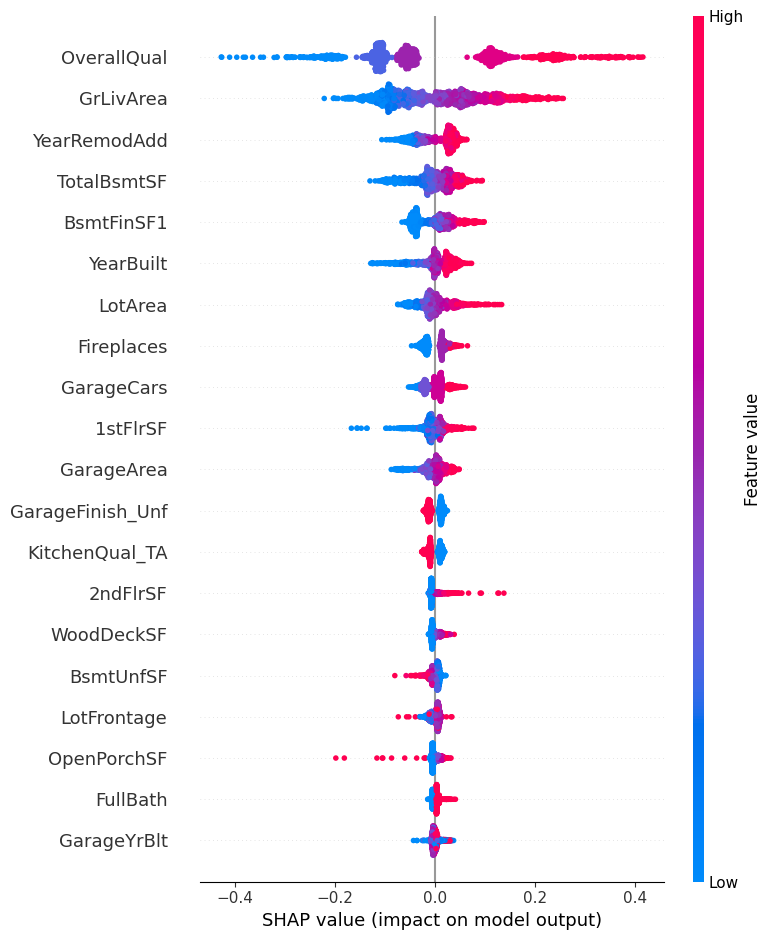

In [7]:
# 🔍 SHAP Dependence Plot pour la variable la plus influente
shap.dependence_plot("OverallQual", shap_values, X_train_sel)

# 💾 Sauvegarde du SHAP summary plot
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_train_sel, show=False)
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
print("✅ SHAP summary plot sauvegardé dans 'shap_summary_plot.png'")
